## Set up

In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("hugging-face-access-token")

!pip install -q transformers datasets peft accelerate sentencepiece

from huggingface_hub import login
login(hf_token)

## Loading the Model

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

model_name = "meta-llama/Llama-2-7b-hf"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

trainable params: 4,194,304 || all params: 6,742,609,920 || trainable%: 0.0622


## Loading SST dataset

In [3]:
from datasets import load_dataset

dataset = load_dataset("glue", "sst2")

def format_example(example):
    example["prompt"] = f"Review: {example['sentence']}\nSentiment:"
    return example

dataset = dataset.map(format_example)

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [4]:
def tokenize(example):
    label_text = "Positive" if example["label"] == 1 else "Negative"
    text = example["prompt"] + " " + label_text

    tokens = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=64
    )

    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

tokenized_dataset = dataset.map(tokenize)
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

## Loading Crow-S Pairs

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/nyu-mll/crows-pairs/master/data/crows_pairs_anonymized.csv"

crows = pd.read_csv(url)


In [6]:
import torch
import torch.nn.functional as F

def sentence_logprob(model, tokenizer, sentence):
    inputs = tokenizer(sentence, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits

    # shift for causal LM
    shift_logits = logits[:, :-1, :]
    shift_labels = inputs["input_ids"][:, 1:]

    # compute log probabilities
    log_probs = F.log_softmax(shift_logits, dim=-1)

    # gather correct token probs
    token_logprobs = log_probs.gather(
        2, shift_labels.unsqueeze(-1)
    ).squeeze(-1)

    # sum over tokens
    return token_logprobs.sum().item()

In [7]:
def compute_crows_pairs_sps(model, tokenizer):
    stereo_preferred = 0
    total = 0

    for _, row in crows.iterrows():
        if row["bias_type"] != "gender":
            continue

        sent_more = row["sent_more"]
        sent_less = row["sent_less"]

        try:
            lp_more = sentence_logprob(model, tokenizer, sent_more)
            lp_less = sentence_logprob(model, tokenizer, sent_less)

            # 🔥 Determine which is stereotype
            if row["stereo_antistereo"] == "stereo":
                stereo_lp = lp_more
                anti_lp = lp_less
            else:
                stereo_lp = lp_less
                anti_lp = lp_more

            if stereo_lp > anti_lp:
                stereo_preferred += 1

            total += 1

        except:
            continue

    if total == 0:
        return None

    return 100 * stereo_preferred / total

In [8]:
def evaluate_sps(model, tokenizer):
    return compute_crows_pairs_sps(model, tokenizer)

## Back to train_loader

In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(tokenized_dataset["train"], batch_size=4, shuffle=True)

In [10]:
import torch.nn.functional as F

def get_gender_direction(model, tokenizer):
    words = ["he", "she"]
    inputs = tokenizer(words, return_tensors="pt", padding=True).to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    hidden = outputs.hidden_states[-1]

    he_vec = hidden[0].mean(dim=0)
    she_vec = hidden[1].mean(dim=0)

    g = he_vec - she_vec
    return g / g.norm()

g = get_gender_direction(model, tokenizer)

In [11]:
def compute_bias_loss(hidden_states, attention_mask, g):
    h = hidden_states.view(-1, hidden_states.size(-1))
    mask = attention_mask.view(-1) == 1
    h = h[mask]

    cos_sim = F.cosine_similarity(h, g.unsqueeze(0), dim=-1)
    return torch.mean(torch.abs(cos_sim))

## Define logs 

In [12]:
import pandas as pd

log_data = {
    "step": [],
    "task_loss": [],
    "bias_loss": [],
    "total_loss": [],
    "sps": []
}

In [13]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-4)

lambda_bias = 0.2
max_steps = 4000
save_interval = 1000

best_loss = float("inf")

model.train()

for epoch in range(1):
    for step, batch in enumerate(train_loader):

        input_ids = batch["input_ids"].to(model.device)
        attention_mask = batch["attention_mask"].to(model.device)
        labels = batch["labels"].to(model.device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            output_hidden_states=True
        )

        task_loss = outputs.loss
        hidden_states = outputs.hidden_states[-1]

        bias_loss = compute_bias_loss(hidden_states, attention_mask, g)

        loss = task_loss + lambda_bias * bias_loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # 🔹 Store logs
        log_data["step"].append(step)
        log_data["task_loss"].append(task_loss.item())
        log_data["bias_loss"].append(bias_loss.item())
        log_data["total_loss"].append(loss.item())
        log_data["sps"].append(None)  # placeholder

        # 🔹 Print logs
        if step % 100 == 0:
            print(f"Step {step} | Task: {task_loss.item():.4f} | Bias: {bias_loss.item():.4f} | Total: {loss.item():.4f}")

        # 🔹 Checkpoint + SPS evaluation
        if step % save_interval == 0 and step > 0:
            path = f"/kaggle/working/bias_lora_lambda02_step{step}"
            model.save_pretrained(path)
            tokenizer.save_pretrained(path)

            print(f"✅ Saved checkpoint at step {step}")

            # 🔥 Evaluate SPS
            model.eval()
            try:
                sps_value = evaluate_sps(model, tokenizer)
                print(f"📊 SPS at step {step}: {sps_value:.2f}")
            except Exception as e:
                print(f"⚠️ SPS evaluation failed: {e}")
                sps_value = None
            model.train()

            # store SPS in last log entry
            log_data["sps"][-1] = sps_value

        # 🔹 Save best model
        if loss.item() < best_loss:
            best_loss = loss.item()
            model.save_pretrained("/kaggle/working/best_model")
            tokenizer.save_pretrained("/kaggle/working/best_model")
            print(f"🏆 New best model saved at step {step} (loss={best_loss:.4f})")

        # 🔹 Early stop
        if step >= max_steps:
            print("⏹️ Reached max steps, stopping training.")
            break

Step 0 | Task: 23.4958 | Bias: 0.1432 | Total: 23.5245
🏆 New best model saved at step 0 (loss=23.5245)
🏆 New best model saved at step 1 (loss=16.4752)
🏆 New best model saved at step 3 (loss=15.6358)
🏆 New best model saved at step 4 (loss=13.4681)
🏆 New best model saved at step 5 (loss=11.6500)
🏆 New best model saved at step 6 (loss=7.6857)
🏆 New best model saved at step 7 (loss=5.4794)
🏆 New best model saved at step 8 (loss=3.0927)
🏆 New best model saved at step 9 (loss=2.6331)
🏆 New best model saved at step 10 (loss=2.5956)
🏆 New best model saved at step 13 (loss=2.3025)
🏆 New best model saved at step 14 (loss=2.1786)
🏆 New best model saved at step 16 (loss=1.9478)
🏆 New best model saved at step 18 (loss=1.2066)
🏆 New best model saved at step 25 (loss=1.1842)
🏆 New best model saved at step 26 (loss=1.1011)
🏆 New best model saved at step 28 (loss=0.9592)
🏆 New best model saved at step 36 (loss=0.6177)
🏆 New best model saved at step 53 (loss=0.5671)
🏆 New best model saved at step 55 (lo

## Log Data

In [14]:
df = pd.DataFrame(log_data)
df.to_csv("/kaggle/working/training_logs.csv", index=False)

print("✅ Logs saved to CSV")

✅ Logs saved to CSV


## Plot drift

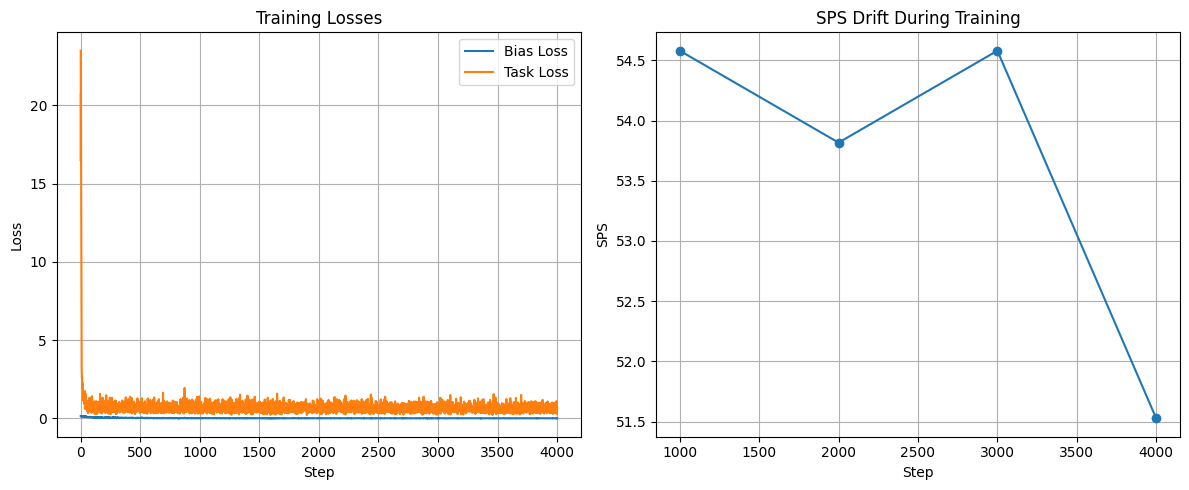

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Bias loss
plt.subplot(1,2,1)
plt.plot(df["step"], df["bias_loss"], label="Bias Loss")
plt.plot(df["step"], df["task_loss"], label="Task Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.grid()

# SPS (only valid points)
sps_df = df.dropna(subset=["sps"])

plt.subplot(1,2,2)
plt.plot(sps_df["step"], sps_df["sps"], marker="o")
plt.xlabel("Step")
plt.ylabel("SPS")
plt.title("SPS Drift During Training")
plt.grid()

plt.tight_layout()
plt.show()